# **Box Plots**

In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.

## Objectives

In this lab you will perform the following:

-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.

### Setup: Connecting to the Database

#### 1. Download the Database File

In [1]:
import urllib.request

# Database URL
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite"

# Download database
urllib.request.urlretrieve(
    url,
    "survey-data.sqlite"
)

print("Database downloaded successfully.")

Database downloaded successfully.


#### 2. Connect to the Database

**Install the needed libraries**

In [2]:
#!pip install pandas

In [3]:
#!pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to SQLite database
conn = sqlite3.connect("survey-data.sqlite")

print("Connected successfully.")

Connected successfully.


## Demo: Basic SQL Queries

#### Demo 1: Count the Number of Rows in the Table

In [5]:
# SQL query to count total rows in the table

query = """
SELECT COUNT(*) AS total_rows
FROM main
"""

# Execute query
row_count = pd.read_sql_query(query, conn)

# Display result
print(row_count)

   total_rows
0       65437


#### Demo 2: List All Tables

In [6]:
# SQL query to list all tables in the database

query = """
SELECT name
FROM sqlite_master
WHERE type='table'
"""

# Execute query
tables = pd.read_sql_query(query, conn)

# Display table names
print(tables)

   name
0  main


#### Demo 3: Group Data by Age

In [7]:
# SQL query to group respondents by Age

query = """
SELECT Age,
       COUNT(*) AS Respondent_Count
FROM main
GROUP BY Age
ORDER BY Respondent_Count DESC
"""

# Execute query
age_df = pd.read_sql_query(query, conn)

# Display results
print(age_df)

                  Age  Respondent_Count
0     25-34 years old             23911
1     35-44 years old             14942
2     18-24 years old             14098
3     45-54 years old              6249
4     55-64 years old              2575
5  Under 18 years old              2568
6   65 years or older               772
7   Prefer not to say               322


## Visualizing Data

### Task 1: Visualizing the Distribution of Data

**1. Box Plot of `CompTotal` (Total Compensation)**

Use a box plot to analyze the distribution and outliers in total compensation.

In [8]:
# SQL query to fetch CompTotal values

query = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL
"""

comp_df = pd.read_sql_query(query, conn)

# Display first few rows
print(comp_df.head())

   CompTotal
0  2040000.0
1    28000.0
2    85000.0
3    50000.0
4   110000.0


In [12]:
# Remove extreme outliers using 99th percentile
# (improves box plot readability)

upper_limit = comp_df['CompTotal'].quantile(0.99)

filtered_comp = comp_df[
    comp_df['CompTotal'] <= upper_limit
]

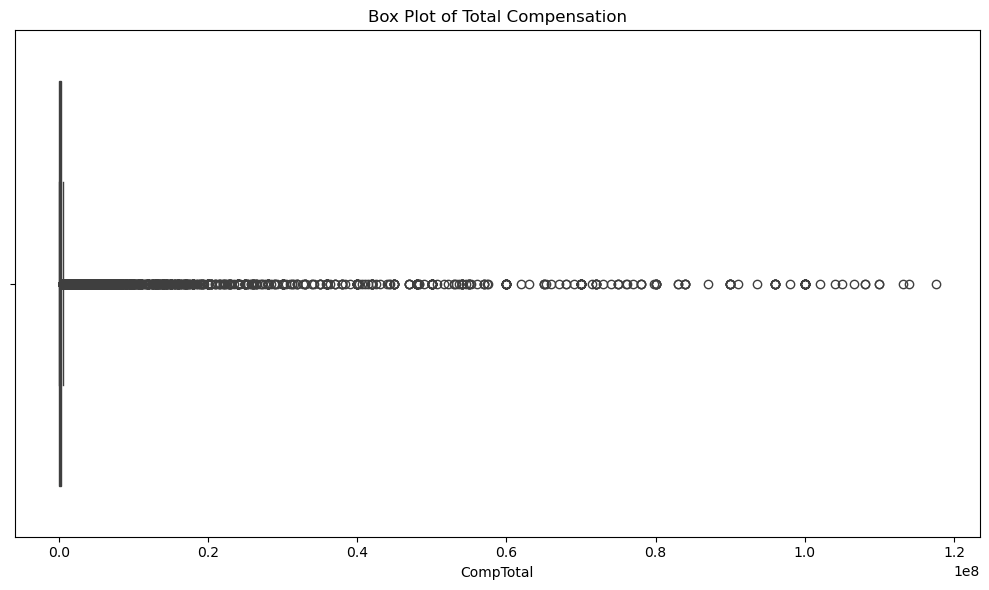

In [13]:
# Create box plot
import seaborn as sns
plt.figure(figsize=(10,6))

sns.boxplot(
    x=filtered_comp['CompTotal']
)

plt.title('Box Plot of Total Compensation')
plt.xlabel('CompTotal')

plt.tight_layout()
plt.show()

**2. Box Plot of Age (converted to numeric values)**

Convert the `Age` column into numerical values and visualize the distribution.

In [14]:
# SQL query to fetch Age values

query = """
SELECT Age
FROM main
WHERE Age IS NOT NULL
"""

age_df = pd.read_sql_query(query, conn)

# Display first few rows
print(age_df.head())

                  Age
0  Under 18 years old
1     35-44 years old
2     45-54 years old
3     18-24 years old
4     18-24 years old


In [15]:
# Convert Age categories into approximate numeric values

age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

age_df['Age_numeric'] = age_df['Age'].map(age_mapping)

# Remove missing values after mapping
age_df = age_df.dropna()

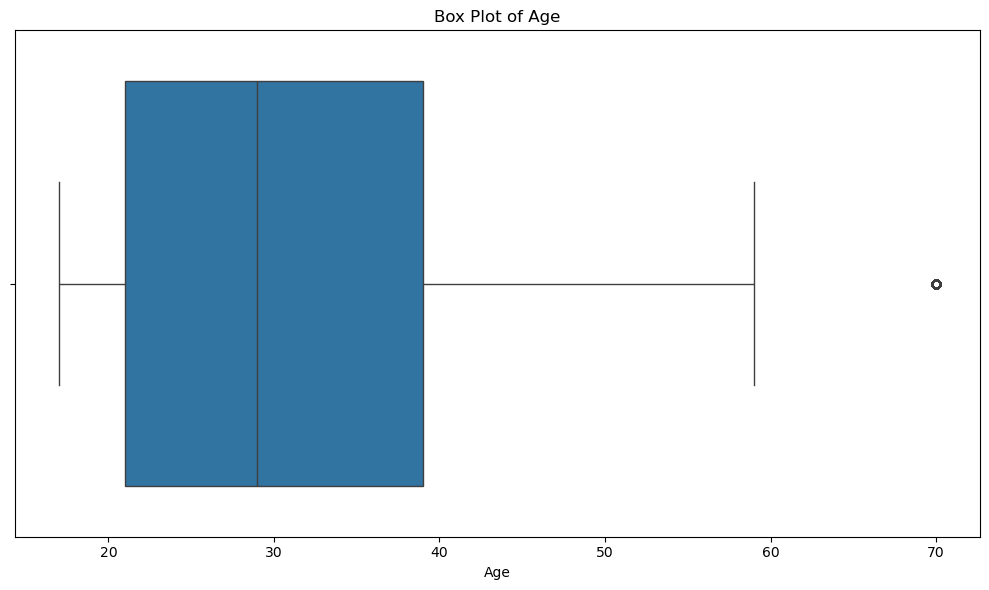

In [16]:
# Create box plot for Age

plt.figure(figsize=(10,6))

sns.boxplot(
    x=age_df['Age_numeric']
)

plt.title('Box Plot of Age')
plt.xlabel('Age')

plt.tight_layout()
plt.show()

### Task 2: Visualizing Relationships in Data

**1. Box Plot of `CompTotal` Grouped by Age Groups:**

Visualize the distribution of compensation across different age groups.

In [17]:
# SQL query to fetch Age and CompTotal

query = """
SELECT Age, CompTotal
FROM main
WHERE Age IS NOT NULL
  AND CompTotal IS NOT NULL
"""

comp_age_df = pd.read_sql_query(query, conn)

# Display first few rows
print(comp_age_df.head())

               Age  CompTotal
0  18-24 years old  2040000.0
1  25-34 years old    28000.0
2  35-44 years old    85000.0
3  35-44 years old    50000.0
4  25-34 years old   110000.0


In [18]:
# Remove extreme outliers for better visualization

upper_limit = comp_age_df['CompTotal'].quantile(0.99)

filtered_df = comp_age_df[
    comp_age_df['CompTotal'] <= upper_limit
]

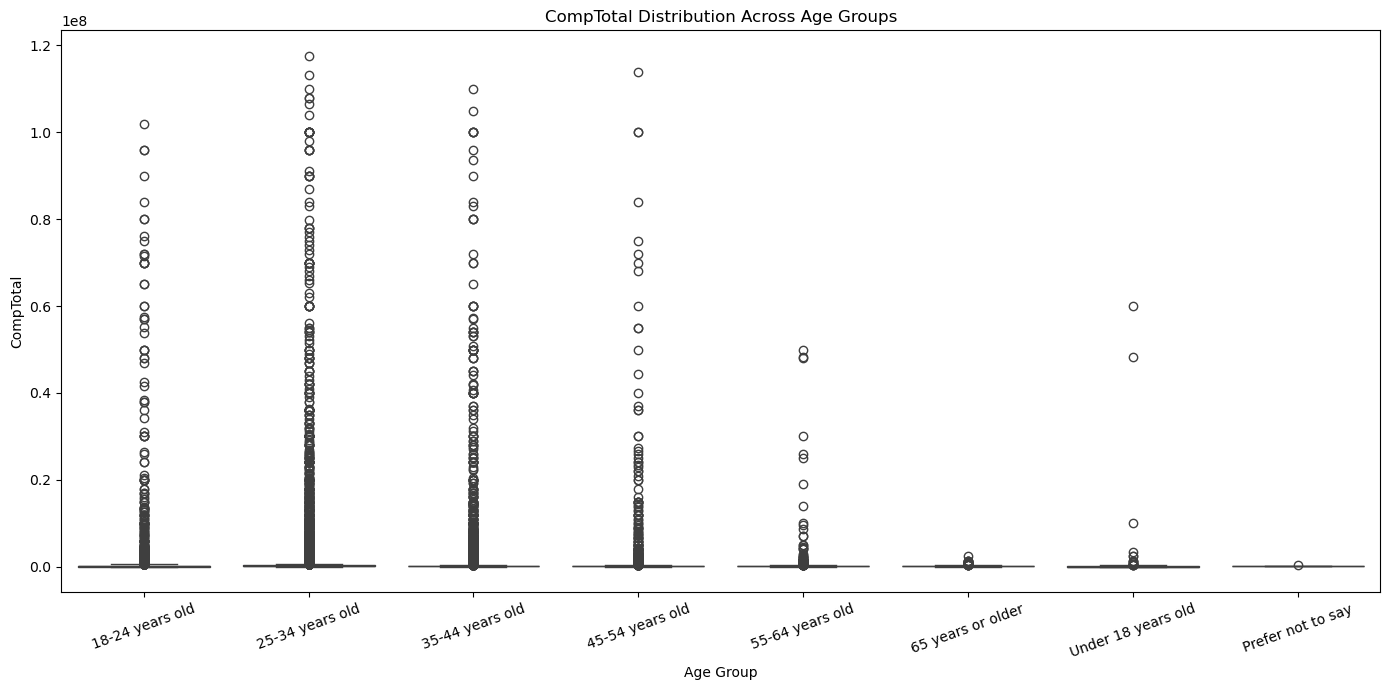

In [19]:
# Create box plot grouped by Age

plt.figure(figsize=(14,7))

sns.boxplot(
    data=filtered_df,
    x='Age',
    y='CompTotal'
)

plt.title('CompTotal Distribution Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('CompTotal')

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**

Examine how compensation varies based on job satisfaction levels.

In [20]:
# SQL query to fetch JobSatPoints_6 and CompTotal

query = """
SELECT JobSatPoints_6, CompTotal
FROM main
WHERE JobSatPoints_6 IS NOT NULL
  AND CompTotal IS NOT NULL
"""

jobsat_comp_df = pd.read_sql_query(query, conn)

# Display first few rows
print(jobsat_comp_df.head())

   JobSatPoints_6  CompTotal
0            65.0  2040000.0
1             0.0    85000.0
2            20.0   110000.0
3            30.0   126420.0
4            30.0   195000.0


In [21]:
# Remove extreme compensation outliers for better visualization

upper_limit = jobsat_comp_df['CompTotal'].quantile(0.99)

filtered_df = jobsat_comp_df[
    jobsat_comp_df['CompTotal'] <= upper_limit
]

In [23]:
# Create explicit copy to avoid SettingWithCopyWarning

filtered_df = filtered_df.copy()

# Convert JobSatPoints_6 into integer values

filtered_df.loc[:, 'JobSatPoints_6'] = (
    filtered_df['JobSatPoints_6']
    .astype(int)
)

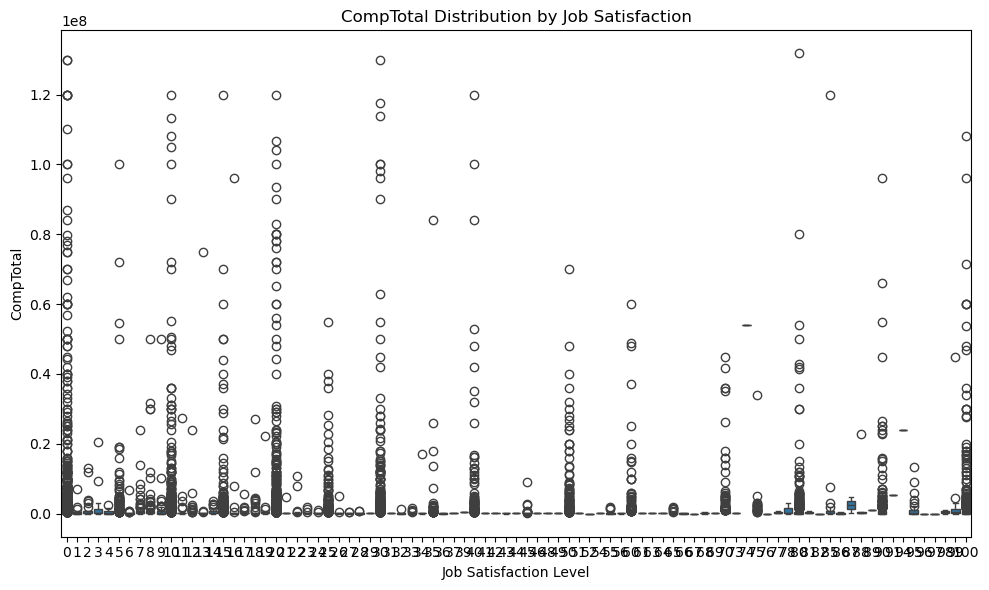

In [24]:
# Create box plot grouped by JobSatPoints_6

plt.figure(figsize=(10,6))

sns.boxplot(
    data=filtered_df,
    x='JobSatPoints_6',
    y='CompTotal'
)

plt.title('CompTotal Distribution by Job Satisfaction')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('CompTotal')

plt.tight_layout()
plt.show()

### Task 3: Visualizing the Composition of Data

**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**

Analyze compensation across the top 5 developer roles.

In [25]:
# SQL query to fetch DevType and ConvertedCompYearly

query = """
SELECT DevType, ConvertedCompYearly
FROM main
WHERE DevType IS NOT NULL
  AND ConvertedCompYearly IS NOT NULL
"""

dev_df = pd.read_sql_query(query, conn)

# Display first few rows
print(dev_df.head())

                                         DevType  ConvertedCompYearly
0  Data scientist or machine learning specialist               7322.0
1                            Academic researcher              30074.0
2  Data scientist or machine learning specialist              91295.0
3                            Developer, back-end              53703.0
4                                        Student             110000.0


In [26]:
# Split multiple developer roles

dev_exploded = dev_df.assign(
    DevType=dev_df['DevType'].str.split(';')
).explode('DevType')

In [27]:
# Find top 5 developer roles

top_5_roles = (
    dev_exploded['DevType']
    .value_counts()
    .head(5)
    .index
)

print(top_5_roles)

Index(['Developer, full-stack', 'Developer, back-end', 'Developer, front-end',
       'Developer, desktop or enterprise applications', 'Developer, mobile'],
      dtype='object', name='DevType')


In [28]:
# Filter only top 5 roles

filtered_df = dev_exploded[
    dev_exploded['DevType'].isin(top_5_roles)
].copy()

In [29]:
# Remove extreme compensation outliers

upper_limit = filtered_df['ConvertedCompYearly'].quantile(0.99)

filtered_df = filtered_df[
    filtered_df['ConvertedCompYearly'] <= upper_limit
]

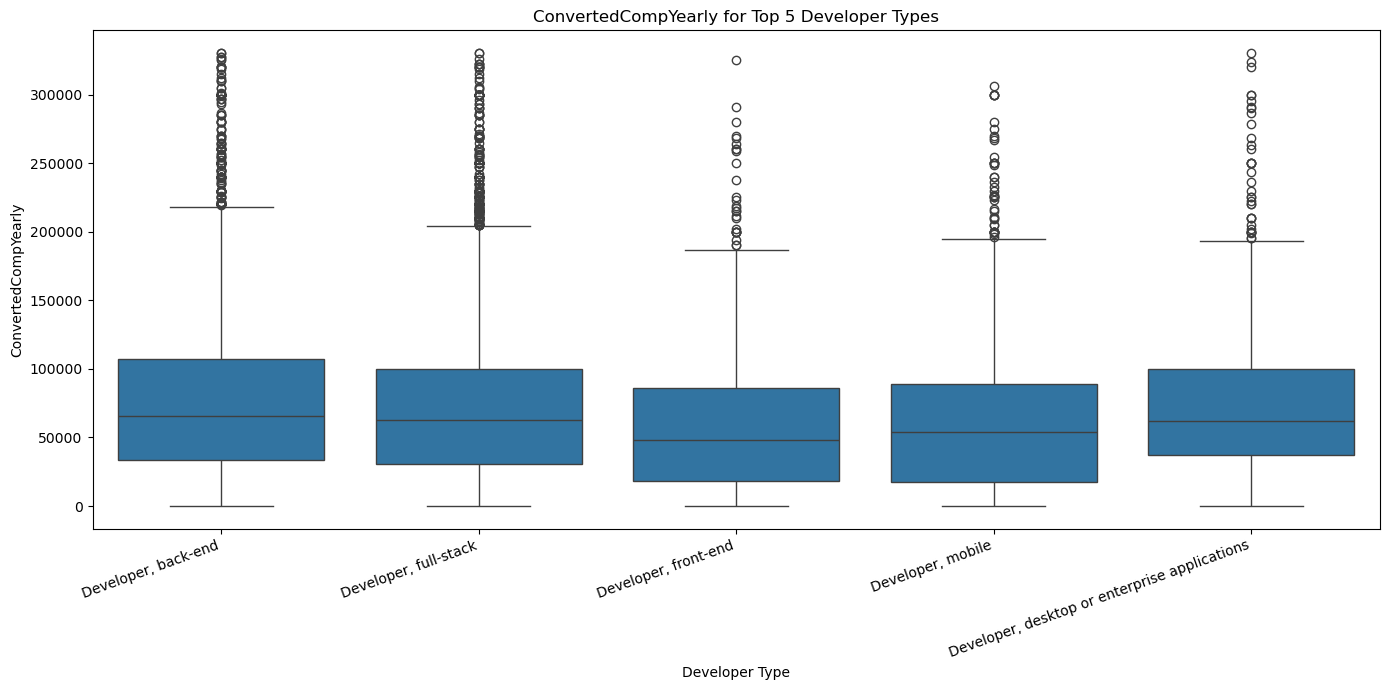

In [30]:
# Create box plot

plt.figure(figsize=(14,7))

sns.boxplot(
    data=filtered_df,
    x='DevType',
    y='ConvertedCompYearly'
)

plt.title('ConvertedCompYearly for Top 5 Developer Types')
plt.xlabel('Developer Type')
plt.ylabel('ConvertedCompYearly')

plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**

Analyze compensation across respondents from the top 5 countries.

In [31]:
# SQL query to fetch Country and CompTotal

query = """
SELECT Country, CompTotal
FROM main
WHERE Country IS NOT NULL
  AND CompTotal IS NOT NULL
"""

country_df = pd.read_sql_query(query, conn)

# Display first few rows
print(country_df.head())

                    Country  CompTotal
0                  Pakistan  2040000.0
1                   Austria    28000.0
2                    Turkey    85000.0
3                    France    50000.0
4  United States of America   110000.0


In [32]:
# Find top 5 countries by respondent count

top_5_countries = (
    country_df['Country']
    .value_counts()
    .head(5)
    .index
)

print(top_5_countries)

Index(['United States of America', 'Germany',
       'United Kingdom of Great Britain and Northern Ireland', 'Ukraine',
       'India'],
      dtype='object', name='Country')


In [33]:
# Filter only top 5 countries

filtered_df = country_df[
    country_df['Country'].isin(top_5_countries)
].copy()

In [34]:
# Remove extreme compensation outliers

upper_limit = filtered_df['CompTotal'].quantile(0.99)

filtered_df = filtered_df[
    filtered_df['CompTotal'] <= upper_limit
]

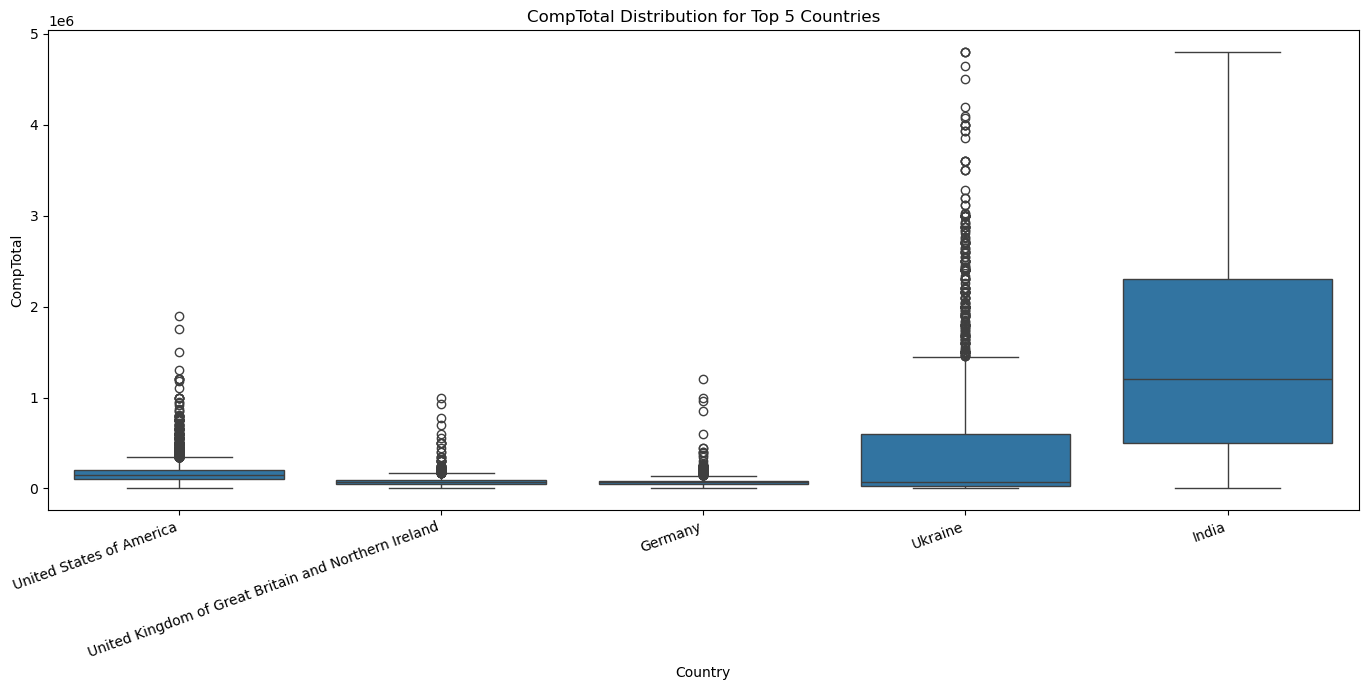

In [35]:
# Create box plot

plt.figure(figsize=(14,7))

sns.boxplot(
    data=filtered_df,
    x='Country',
    y='CompTotal'
)

plt.title('CompTotal Distribution for Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('CompTotal')

plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.show()

### Task 4: Visualizing Comparison of Data

**1. Box Plot of CompTotal Across Employment Types:**

Analyze compensation for different employment types.

In [36]:
# SQL query to fetch Employment and CompTotal

query = """
SELECT Employment, CompTotal
FROM main
WHERE Employment IS NOT NULL
  AND CompTotal IS NOT NULL
"""

employment_df = pd.read_sql_query(query, conn)

# Display first few rows
print(employment_df.head())

                                          Employment  CompTotal
0  Employed, full-time;Student, full-time;Indepen...  2040000.0
1                                Employed, full-time    28000.0
2                                Employed, full-time    85000.0
3  Independent contractor, freelancer, or self-em...    50000.0
4             Employed, full-time;Student, part-time   110000.0


In [37]:
# Find top employment types

top_employment = (
    employment_df['Employment']
    .value_counts()
    .head(5)
    .index
)

print(top_employment)

Index(['Employed, full-time',
       'Independent contractor, freelancer, or self-employed',
       'Employed, full-time;Independent contractor, freelancer, or self-employed',
       'Employed, part-time', 'Employed, full-time;Student, part-time'],
      dtype='object', name='Employment')


In [38]:
# Filter top employment types

filtered_df = employment_df[
    employment_df['Employment'].isin(top_employment)
].copy()

In [39]:
# Remove extreme compensation outliers

upper_limit = filtered_df['CompTotal'].quantile(0.99)

filtered_df = filtered_df[
    filtered_df['CompTotal'] <= upper_limit
]

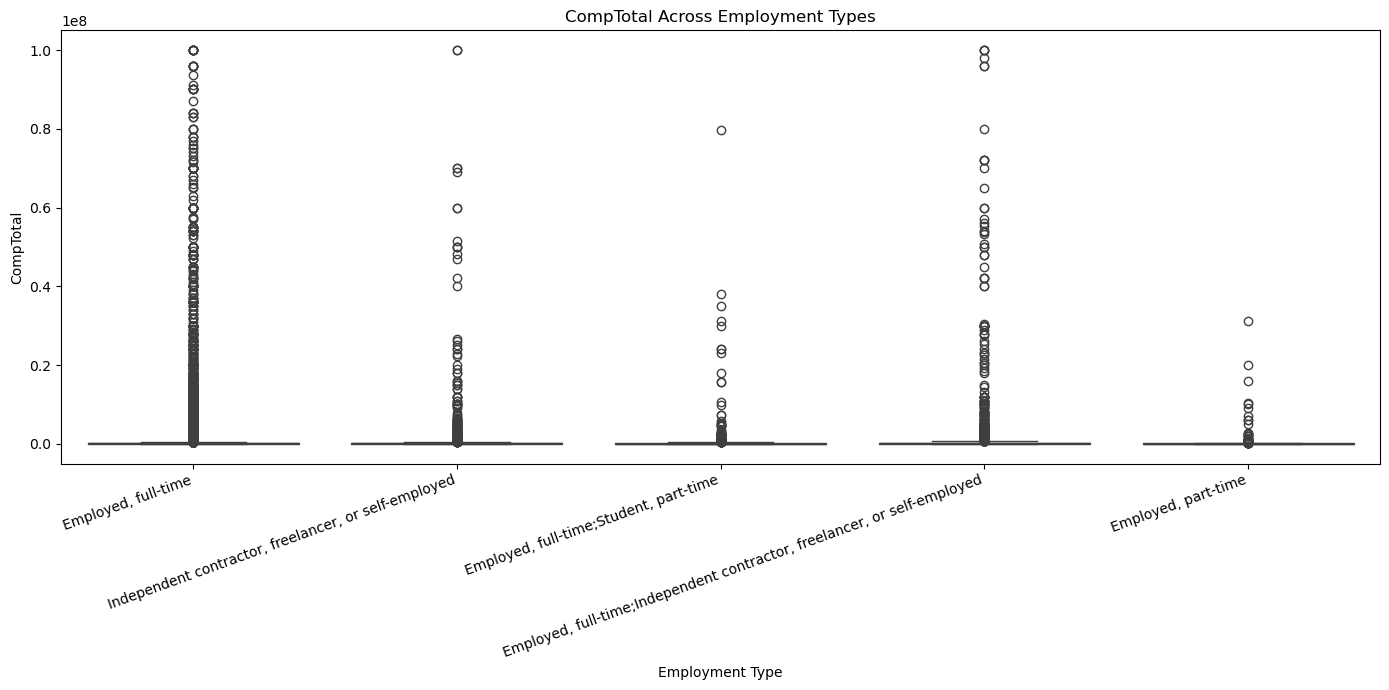

In [40]:
# Create box plot

plt.figure(figsize=(14,7))

sns.boxplot(
    data=filtered_df,
    x='Employment',
    y='CompTotal'
)

plt.title('CompTotal Across Employment Types')
plt.xlabel('Employment Type')
plt.ylabel('CompTotal')

plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**

Examine the distribution of professional coding years by job satisfaction levels.

In [41]:
# SQL query to fetch YearsCodePro and JobSatPoints_6

query = """
SELECT YearsCodePro, JobSatPoints_6
FROM main
WHERE YearsCodePro IS NOT NULL
  AND JobSatPoints_6 IS NOT NULL
"""

years_jobsat_df = pd.read_sql_query(query, conn)

# Display first few rows
print(years_jobsat_df.head())

       YearsCodePro  JobSatPoints_6
0                17             0.0
1                12            30.0
2                27             0.0
3                10            60.0
4  Less than 1 year           100.0


In [42]:
# Convert columns to numeric

years_jobsat_df['YearsCodePro'] = pd.to_numeric(
    years_jobsat_df['YearsCodePro'],
    errors='coerce'
)

years_jobsat_df['JobSatPoints_6'] = pd.to_numeric(
    years_jobsat_df['JobSatPoints_6'],
    errors='coerce'
)

# Remove missing values
years_jobsat_df = years_jobsat_df.dropna()

In [43]:
# Convert JobSatPoints_6 into integer values

years_jobsat_df['JobSatPoints_6'] = (
    years_jobsat_df['JobSatPoints_6']
    .astype(int)
)

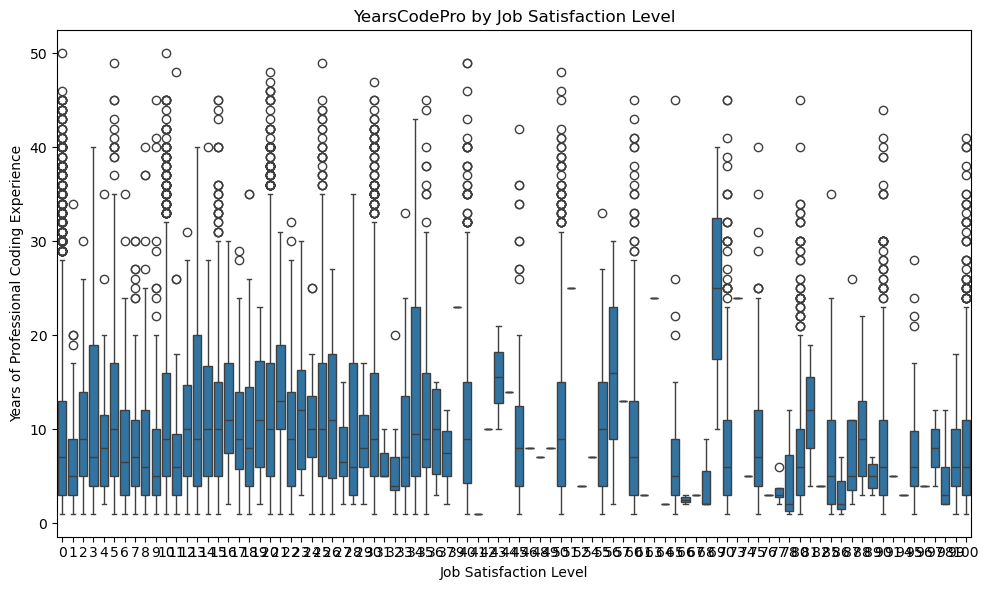

In [44]:
# Create box plot

plt.figure(figsize=(10,6))

sns.boxplot(
    data=years_jobsat_df,
    x='JobSatPoints_6',
    y='YearsCodePro'
)

plt.title('YearsCodePro by Job Satisfaction Level')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Years of Professional Coding Experience')

plt.tight_layout()
plt.show()

### Final Step: Close the Database Connection

After completing the lab, close the connection to the SQLite database:

In [45]:
conn.close()

## Summary

In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.